In [51]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")

In [52]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cuda:0


In [53]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_LMP_Forecasts", "FR_lmp_processed.csv")
DATA_CSV_DE = os.path.join("data", "DE_LMP_Forecasts", "DE_lmp_processed.csv")
DATA_CSV_ES = os.path.join("data", "ESP_LMP_Forecasts", "ES_lmp_processed.csv")
DATA_CSV_BE = os.path.join("data", "BE_LMP_Forecasts", "BE_lmp_processed.csv")
def split_data(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    train = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2023-09-30')].reset_index(drop=True)
    dev   = df[(df['date'] >= '2023-10-01') & (df['date'] <= '2024-09-30')].reset_index(drop=True)
    test  = df[(df['date'] >= '2024-10-01') & (df['date'] <= '2025-09-30')].reset_index(drop=True)
    return train, dev, test

def create_sliding_window(data_df, window_size, forecast_horizon=24):
    X, y = [], []
    series = data_df['EUR/MWh'].values
    for i in range(len(series) - window_size - forecast_horizon + 1):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size:i+window_size+forecast_horizon])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)


In [54]:

# --- Model (MLP) similar structure to Rolling window notebook ---
class MLP(nn.Module):
    def __init__(self, input_dim, layer_dims, output_dim, dropout=0.0, use_batchnorm=False, leaky_alpha=0.0):
        super().__init__()
        layers = []
        last = input_dim
        for i, d in enumerate(layer_dims):
            layers.append(nn.Linear(last, d))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(d, eps=1e-3, momentum=0.99))
            if leaky_alpha and leaky_alpha > 0:
                layers.append(nn.LeakyReLU(leaky_alpha))
            else:
                layers.append(nn.ReLU())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            last = d
        layers.append(nn.Linear(last, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [55]:

# MAE loss (matches TF mae)
def mae_loss_fn(pred, target):
    return torch.mean(torch.abs(pred - target))


In [56]:

# evaluate model: predict and compute MAE and rMAE vs naive 7-day baseline
def evaluate_model(model, X_np, y_np, shift=24*7, batch_size=128, device='cpu'):
    model.to(device)
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.from_numpy(X_np[i:i+batch_size]).to(device)
            out = model(xb).cpu().numpy()
            preds.append(out)
    predictions = np.vstack(preds)
    if len(y_np) <= shift:
        raise ValueError("Not enough samples to compute naive baseline (need > shift samples).")
    naive_baseline = np.empty_like(y_np, dtype=float)
    naive_baseline[:shift, :] = np.nan
    naive_baseline[shift:, :] = y_np[:-shift, :]
    preds_trim = predictions[shift:]
    true = y_np[shift:]
    naive = naive_baseline[shift:]
    mae_model = np.mean(np.abs(preds_trim - true))
    mae_naive = np.mean(np.abs(naive - true))
    if mae_naive == 0:
        rmae = np.inf
        accuracy = -np.inf
    else:
        rmae = mae_model / mae_naive
        accuracy = 1.0 - rmae
    print(f"MAE model: {mae_model:.6f}, MAE naive: {mae_naive:.6f}")
    print(f"Relative MAE (rMAE): {rmae:.4f}, Accuracy (1-rMAE): {accuracy:.4f}")
    return {"predictions": preds_trim, "mae_model": mae_model, "mae_naive": mae_naive, "rmae": rmae, "accuracy": accuracy}


In [57]:

# --- Training routine adapted to fullRun.py style, using MAE and optional L1 ---
def run_full_train(
        X_train_np, y_train_np, X_dev_np, y_dev_np,
        layer_dims,
        dropout,
        use_batchnorm,
        leaky_alpha,
        learning_rate,
        weight_decay,
        l1_lambda,
        batch_size,
        train_amt,
        epochs,
        verbose_freq = 1
    ):
    input_dim = X_train_np.shape[1]
    output_dim = y_train_np.shape[1]
    MODEL = MLP(input_dim=input_dim, layer_dims=layer_dims, output_dim=output_dim,
                dropout=dropout, use_batchnorm=use_batchnorm, leaky_alpha=leaky_alpha).to(device)
    optimizer = torch.optim.Adam(MODEL.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, min_lr=1e-6)

    print("Model:")
    print(MODEL)
    print("Optimizer:", optimizer)
    print("Batch size:", batch_size, "Epochs:", epochs)

    train_hist = []
    val_hist = []

    X_train_use = X_train_np[:train_amt]
    y_train_use = y_train_np[:train_amt]

    X_dev_t = torch.from_numpy(X_dev_np).float().to(device)
    y_dev_t = torch.from_numpy(y_dev_np).float().to(device)

    for epoch in range(epochs):
        perm = np.random.permutation(len(X_train_use))
        X_shuf = X_train_use[perm]
        y_shuf = y_train_use[perm]

        MODEL.train()
        epoch_train_loss = 0.0
        n_seen = 0
        for i in range(0, len(X_shuf), batch_size):
            xb = torch.from_numpy(X_shuf[i:i+batch_size]).float().to(device)
            yb = torch.from_numpy(y_shuf[i:i+batch_size]).float().to(device)

            optimizer.zero_grad()
            pred = MODEL(xb)
            loss = mae_loss_fn(pred, yb)
            if l1_lambda and l1_lambda > 0:
                l1 = torch.tensor(0., device=device)
                for p in MODEL.parameters():
                    l1 = l1 + torch.sum(torch.abs(p))
                loss = loss + l1_lambda * l1
            loss.backward()
            optimizer.step()

            bs = xb.size(0)
            epoch_train_loss += loss.item() * bs
            n_seen += bs

        epoch_train_loss /= n_seen
        train_hist.append(epoch_train_loss)

        # validation
        MODEL.eval()
        with torch.no_grad():
            val_loss = 0.0
            n_val = 0
            for i in range(0, len(X_dev_np), batch_size):
                xb = torch.from_numpy(X_dev_np[i:i+batch_size]).float().to(device)
                yb = torch.from_numpy(y_dev_np[i:i+batch_size]).float().to(device)
                pred = MODEL(xb)
                loss = mae_loss_fn(pred, yb)
                val_loss += loss.item() * xb.size(0)
                n_val += xb.size(0)
            val_loss /= n_val
        val_hist.append(val_loss)
        scheduler.step(val_loss)

        if verbose_freq is not None and epoch % verbose_freq == 0:
            print(f"Epoch {epoch+1}/{epochs} train_loss={epoch_train_loss:.6f} val_loss={val_loss:.6f}")

    return MODEL, train_hist, val_hist


In [64]:

# --- Main: load CSV, prepare sliding windows, normalize, quick experiments ---
SEED = 42
seed_everything(SEED)

df_FR = pd.read_csv(DATA_CSV_FR)
df_DE=pd.read_csv(DATA_CSV_DE)
df_ES=pd.read_csv(DATA_CSV_ES)
df_BE=pd.read_csv(DATA_CSV_BE)

train_df_FR, dev_df_FR, test_df_FR = split_data(df_FR)
train_df_DE, dev_df_DE, test_df_DE = split_data(df_DE)
train_df_ES, dev_df_ES, test_df_ES = split_data(df_ES)
train_df_BE, dev_df_BE, test_df_BE = split_data(df_BE)

# --- Combined normalization (recommended) ---
# compute mean/std on the combined training series (FR + DE + ES + BE)
all_train_series = pd.concat([train_df_FR['EUR/MWh'], train_df_DE['EUR/MWh'], train_df_ES['EUR/MWh'], train_df_BE['EUR/MWh']], ignore_index=True)
mean_all = all_train_series.mean()
std_all = all_train_series.std()

# normalize every split (both countries) using combined stats
for df in [train_df_FR, dev_df_FR, test_df_FR, train_df_DE, train_df_ES,train_df_BE]:
    df['EUR/MWh'] = (df['EUR/MWh'] - mean_all) / std_all

# --- Create sliding windows per country ---
t = 168
forecast_horizon = 24

X_train_FR, y_train_FR = create_sliding_window(train_df_FR, t, forecast_horizon)
X_train_DE, y_train_DE = create_sliding_window(train_df_DE, t, forecast_horizon)
X_train_ES, y_train_ES = create_sliding_window(train_df_ES, t, forecast_horizon)
X_train_BE, y_train_BE = create_sliding_window(train_df_BE, t, forecast_horizon)




# --- Combine training examples from both countries ---
X_train = np.vstack([X_train_FR, X_train_DE,X_train_ES,X_train_BE])
y_train = np.vstack([y_train_FR, y_train_DE,y_train_ES,y_train_BE])

# shuffle combined training set
perm = np.random.permutation(len(X_train))
X_train = X_train[perm]
y_train = y_train[perm]



# keep dev/test separate per country (useful to inspect per-country performance)
# keep X_dev_FR, y_dev_FR ; X_dev_DE, y_dev_DE etc.
t = 168
forecast_horizon = 24

X_dev,   y_dev   = create_sliding_window(dev_df_FR, t, forecast_horizon)
X_test,  y_test  = create_sliding_window(test_df_FR, t, forecast_horizon)
print("Combined training samples:", X_train.shape, y_train.shape)
print("Combined dev samples:", X_dev.shape, y_dev.shape)
print("Combined test samples:", X_test.shape, y_test.shape)
# experiment config(s) (keeps logic/content from notebook)
all_exp_params = {
    "default": {
        "layer_dims": [256, 128],
        "dropout": 0.05,
        "use_batchnorm": False,
        "leaky_alpha": 0.1,
        "learning_rate": 3e-4,
        "weight_decay": 1e-4,
        "l1_lambda": 0.0,
        "batch_size": 128,
        "train_amt": len(X_train),   # use all by default
        "epochs": 50
     },
    # "quick_small": {
    #     "layer_dims": [512, 256, 128],
    #     "dropout": 0.2,
    #     "use_batchnorm": True,
    #     "leaky_alpha": 0.01,
    #     "learning_rate": 1e-4,
    #     "weight_decay": 1e-4,
    #     "l1_lambda": 0.0,
    #     "batch_size": 128,
    #     "train_amt": max(500, int(len(X_train)*0.25)),
    #     "epochs": 10
    # }
}

results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}

for tag, params in all_exp_params.items():
    print("Running experiment:", tag)
    model, train_hist, val_hist = run_full_train(
        X_train, y_train, X_dev, y_dev,
        layer_dims = params["layer_dims"],
        dropout = params["dropout"],
        use_batchnorm = params["use_batchnorm"],
        leaky_alpha = params["leaky_alpha"],
        learning_rate = params["learning_rate"],
        weight_decay = params["weight_decay"],
        l1_lambda = params.get("l1_lambda", 0.0),
        batch_size = params["batch_size"],
        train_amt = params["train_amt"],
        epochs = params["epochs"],
        verbose_freq = 1
    )
    # evaluate dev set (rMAE etc)
    print("Evaluating on dev set:")
    eval_res = evaluate_model(model, X_dev, y_dev, device=device)
    exp_results[tag] = {"train_loss": train_hist, "val_loss": val_hist, "eval": eval_res}

save_object_to_file(exp_results, results_save_path)
exp_results = read_object_from_file(results_save_path)

for tag, r in exp_results.items():
    tr = r["train_loss"]
    va = r["val_loss"]
    plt.clf()
    plt.plot(range(len(tr)), tr, label="Train Loss")
    plt.plot(range(len(va)), va, label="Validation Loss")
    plt.title(f"{tag} Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend(loc="upper right")
    plt.savefig(tag + plot_suffix)
    plt.clf()
plt.show()

Combined training samples: (139476, 168) (139476, 24)
Combined dev samples: (8592, 168) (8592, 24)
Combined test samples: (8568, 168) (8568, 24)
Running experiment: default
Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=366, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.05, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.05, inplace=False)
    (6): Linear(in_features=128, out_features=24, bias=True)
  )
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0.0001
)
Batch size: 128 Epochs: 50
Epoch 1/50 train_loss=0.200860 val_loss=0.150598
Epoch 2/50 train_loss=0.168157 val_loss=0.145349
Epoch 3/50 train_loss=0.161578 val_loss=0.142910

<Figure size 640x480 with 0 Axes>

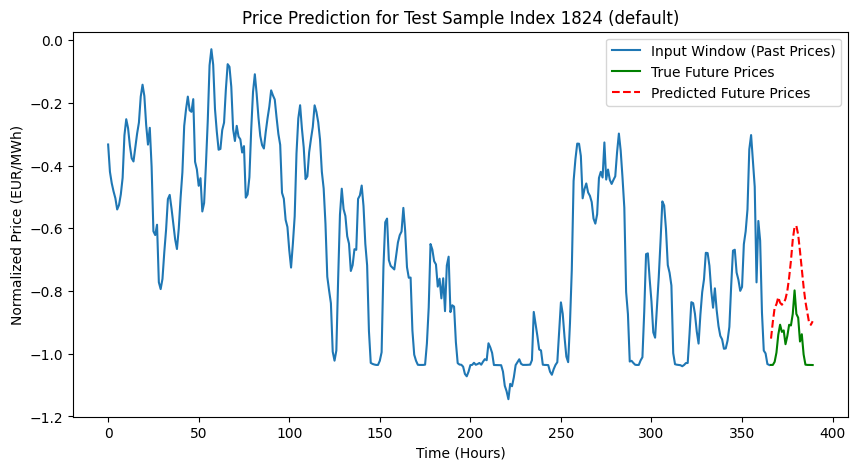

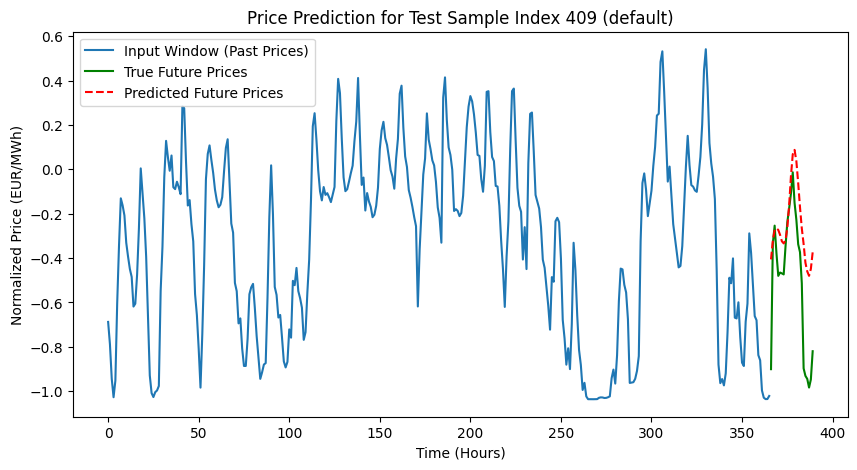

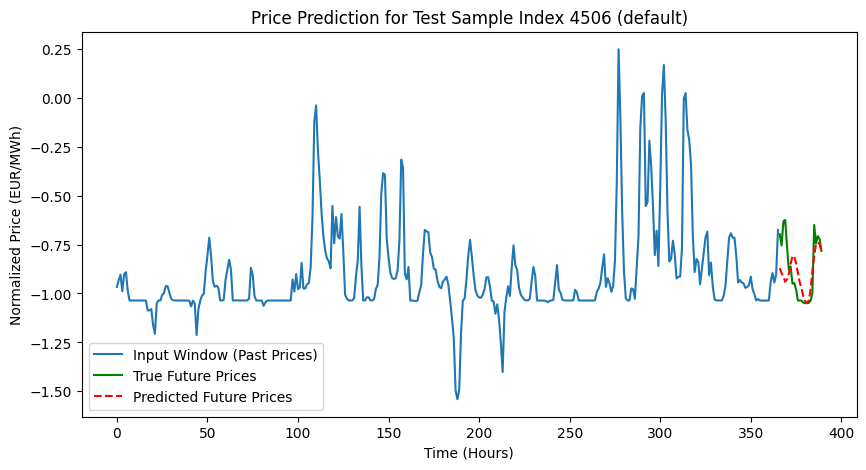

In [59]:
#Pick three days at random on the test set and see how the model predicts


# Pick three random days from the test set
num_days = len(X_test)
random_indices = random.sample(range(num_days), 3)

for idx in random_indices:
    input_window = X_dev[idx]
    true_values = y_dev[idx]

    model.eval()
    with torch.no_grad():
        input_tensor = torch.from_numpy(input_window).float().unsqueeze(0).to(device)
        predicted_values = model(input_tensor).cpu().numpy().flatten()

    plt.figure(figsize=(10, 5))
    plt.plot(range(t), input_window, label='Input Window (Past Prices)')
    plt.plot(range(t, t + forecast_horizon), true_values, label='True Future Prices', color='green')
    plt.plot(range(t, t + forecast_horizon), predicted_values, label='Predicted Future Prices', color='red', linestyle='--')
    #plot a naive baseline behind the prices 24 hours before
    # naive_baseline = input_window[-forecast_horizon:]
    # plt.plot(range(t, t + forecast_horizon), naive_baseline, label='Naive Baseline (24h before)', color='orange', linestyle=':')
    plt.plot()
    plt.title(f'Price Prediction for Test Sample Index {idx} ({tag})')
    plt.xlabel('Time (Hours)')
    plt.ylabel('Normalized Price (EUR/MWh)')
    plt.legend()
    plt.show()